**The Vulnerability Gap (Baselines & Undefended Attacks)**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

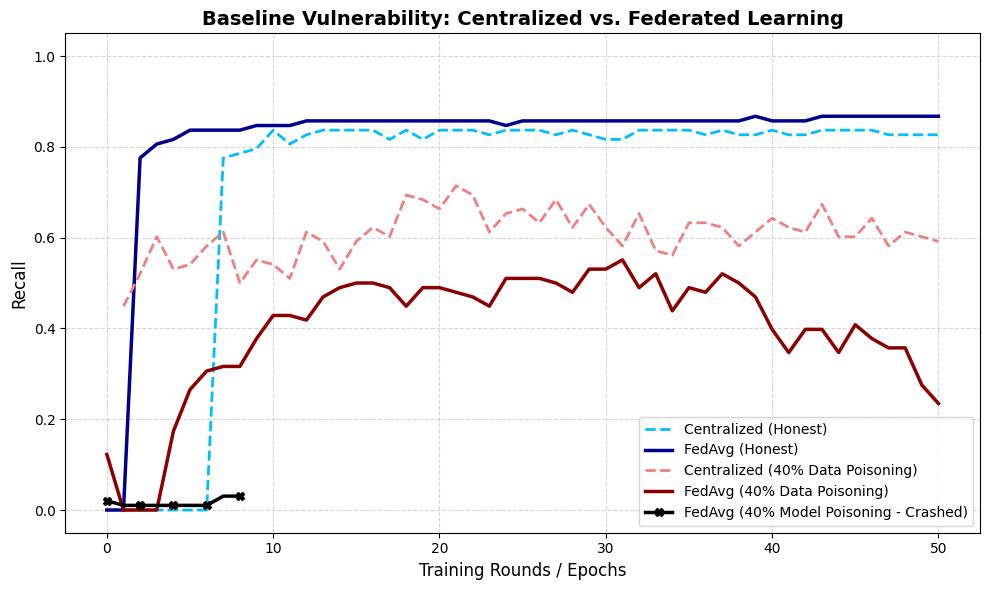

In [4]:
def load_data(filename):
    try:
        return pd.read_csv(f'results/50_rounds/{filename}')
    except FileNotFoundError:
        print(f"Warning: Could not find {filename}")
        return pd.DataFrame()

df_cent_base = load_data('results_centralized_baseline_r50.csv')
df_fl_base = load_data('results_baseline_r50.csv')
df_cent_atk40 = load_data('results_centralized_attack_40_r50.csv')
df_fl_atk40 = load_data('results_attack_40_r50.csv')
df_fl_model_atk40 = load_data('results_attack_40-model-poisoning_r50.csv')

plt.figure(figsize=(10, 6))

if not df_cent_base.empty:
    plt.plot(df_cent_base['Epoch'], df_cent_base['Recall'], label='Centralized (Honest)', color='deepskyblue', linewidth=2, linestyle='--')
if not df_fl_base.empty:
    plt.plot(df_fl_base['Round'], df_fl_base['Recall'], label='FedAvg (Honest)', color='darkblue', linewidth=2.5)

if not df_cent_atk40.empty:
    plt.plot(df_cent_atk40['Epoch'], df_cent_atk40['Recall'], label='Centralized (40% Data Poisoning)', color='lightcoral', linewidth=2, linestyle='--')
if not df_fl_atk40.empty:
    plt.plot(df_fl_atk40['Round'], df_fl_atk40['Recall'], label='FedAvg (40% Data Poisoning)', color='darkred', linewidth=2.5)
if not df_fl_model_atk40.empty:
    plt.plot(df_fl_model_atk40['Round'], df_fl_model_atk40['Recall'], label='FedAvg (40% Model Poisoning - Crashed)', color='black', linewidth=2.5, marker='X', markevery=2)

plt.title('Baseline Vulnerability: Centralized vs. Federated Learning', fontsize=14, fontweight='bold')
plt.xlabel('Training Rounds / Epochs', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig('plot1_vulnerability.png', dpi=300)
plt.show()

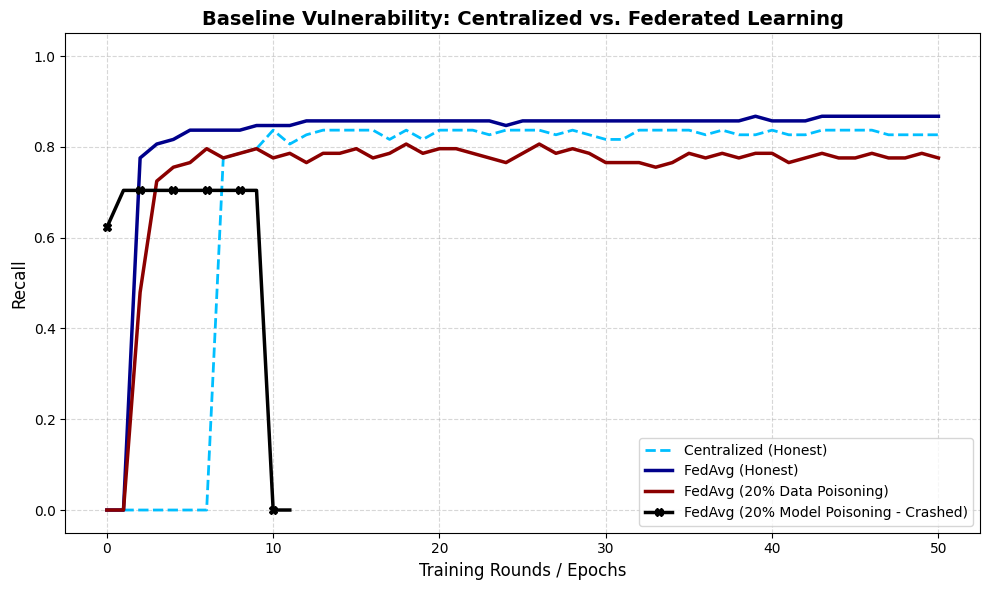

In [4]:
def load_data(filename):
    try:
        return pd.read_csv(f'results/50_rounds/{filename}')
    except FileNotFoundError:
        print(f"Warning: Could not find {filename}")
        return pd.DataFrame()

df_cent_base = load_data('results_centralized_baseline_r50.csv')
df_fl_base = load_data('results_baseline_r50.csv')
#df_cent_atk40 = load_data('results_centralized_attack_40_r50.csv')
df_fl_atk40 = load_data('results_attack_20_r50.csv')
df_fl_model_atk40 = load_data('results_attack_20-model-poisoning_r50.csv')

plt.figure(figsize=(10, 6))

if not df_cent_base.empty:
    plt.plot(df_cent_base['Epoch'], df_cent_base['Recall'], label='Centralized (Honest)', color='deepskyblue', linewidth=2, linestyle='--')
if not df_fl_base.empty:
    plt.plot(df_fl_base['Round'], df_fl_base['Recall'], label='FedAvg (Honest)', color='darkblue', linewidth=2.5)

#if not df_cent_atk40.empty:
    #plt.plot(df_cent_atk40['Epoch'], df_cent_atk40['Recall'], label='Centralized (20% Data Poisoning)', color='lightcoral', linewidth=2, linestyle='--')
if not df_fl_atk40.empty:
    plt.plot(df_fl_atk40['Round'], df_fl_atk40['Recall'], label='FedAvg (20% Data Poisoning)', color='darkred', linewidth=2.5)
if not df_fl_model_atk40.empty:
    plt.plot(df_fl_model_atk40['Round'], df_fl_model_atk40['Recall'], label='FedAvg (20% Model Poisoning - Crashed)', color='black', linewidth=2.5, marker='X', markevery=2)

plt.title('Baseline Vulnerability: Centralized vs. Federated Learning', fontsize=14, fontweight='bold')
plt.xlabel('Training Rounds / Epochs', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot1_vulnerability.png', dpi=300)
plt.show()

**Defending Against Data Poisoning (Side-by-Side)**

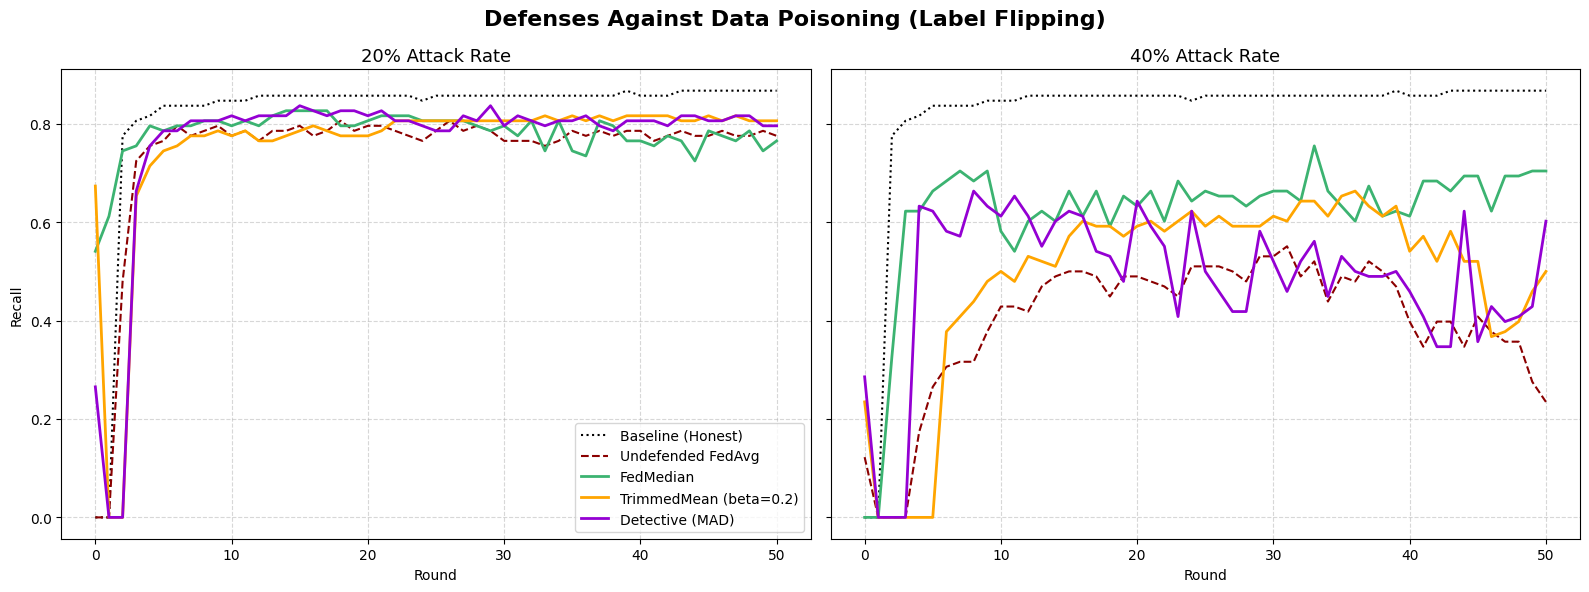

In [ ]:
df_atk20 = load_data('results_attack_20_r50.csv')
df_med20 = load_data('results_defense_Median_20_r50.csv')
df_trim20 = load_data('results_defense_TrimmedMean_20_r50.csv')
df_det20 = load_data('results_detective_20_r50.csv')

df_med40 = load_data('results_defense_Median_40_r50.csv')
df_trim40 = load_data('results_defense_TrimmedMean_40_r50.csv')
df_det40 = load_data('results_detective_40_r50.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Defenses Against Data Poisoning (Label Flipping)', fontsize=16, fontweight='bold')

axes[0].plot(df_fl_base['Round'], df_fl_base['Recall'], label='Baseline (Honest)', color='black', linestyle=':')
axes[0].plot(df_atk20['Round'], df_atk20['Recall'], label='Undefended FedAvg', color='darkred', linestyle='--')
axes[0].plot(df_med20['Round'], df_med20['Recall'], label='FedMedian', color='mediumseagreen', linewidth=2)
axes[0].plot(df_trim20['Round'], df_trim20['Recall'], label='TrimmedMean (beta=0.2)', color='orange', linewidth=2)
axes[0].plot(df_det20['Round'], df_det20['Recall'], label='Detective (MAD)', color='darkviolet', linewidth=2)
axes[0].set_title('20% Attack Rate', fontsize=13)
axes[0].set_ylabel('Recall')
axes[0].set_xlabel('Round')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(df_fl_base['Round'], df_fl_base['Recall'], label='Baseline (Honest)', color='black', linestyle=':')
axes[1].plot(df_fl_atk40['Round'], df_fl_atk40['Recall'], label='Undefended FedAvg', color='darkred', linestyle='--')
axes[1].plot(df_med40['Round'], df_med40['Recall'], label='FedMedian', color='mediumseagreen', linewidth=2)
axes[1].plot(df_trim40['Round'], df_trim40['Recall'], label='TrimmedMean (beta=0.2)', color='orange', linewidth=2)
axes[1].plot(df_det40['Round'], df_det40['Recall'], label='Detective (MAD)', color='darkviolet', linewidth=2)
axes[1].set_title('40% Attack Rate', fontsize=13)
axes[1].set_xlabel('Round')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot2_data_poisoning_defenses.png', dpi=300)
plt.show()

**Defending Against Model Poisoning (The DoS Attack)**

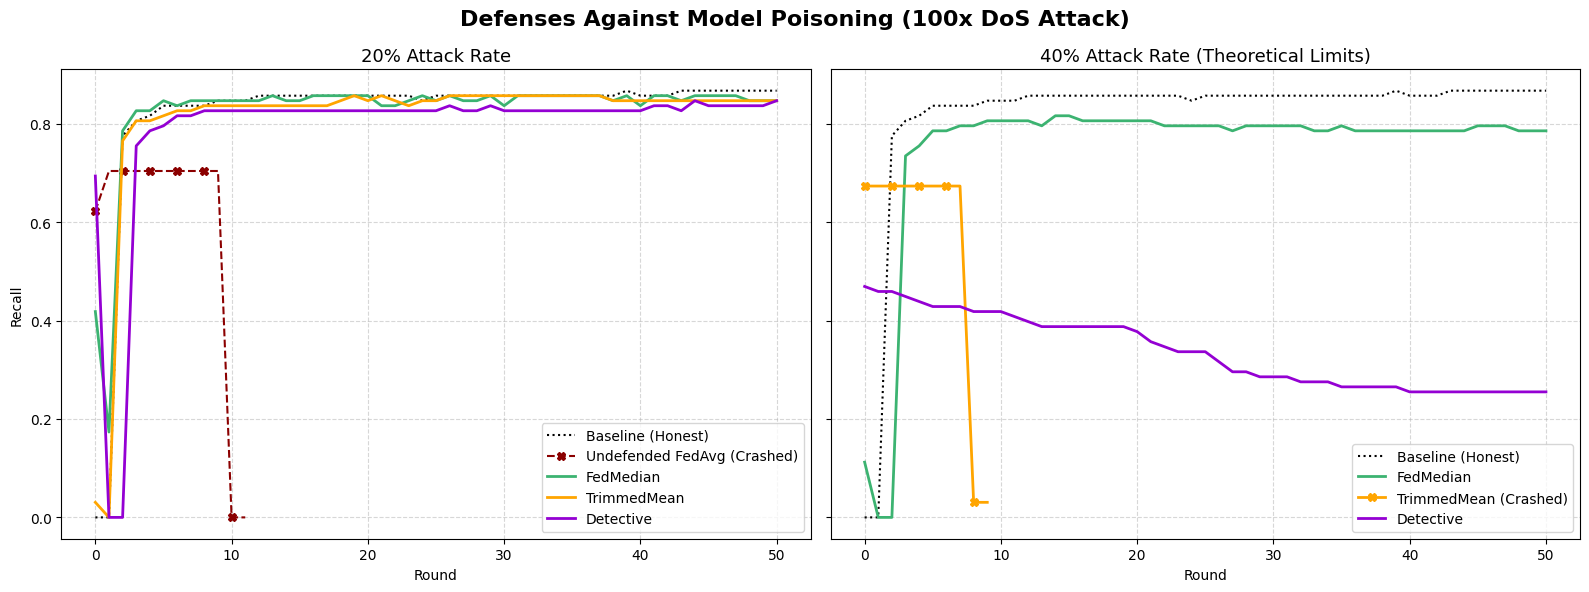

In [ ]:
df_m_atk20 = load_data('results_attack_20-model-poisoning_r50.csv')
df_m_med20 = load_data('results_defense_Median_20-model-poisoning_r50.csv')
df_m_trim20 = load_data('results_defense_TrimmedMean_20-model-poisoning_r50.csv')
df_m_det20 = load_data('results_detective_20-model-poisoning_r50.csv')

df_m_med40 = load_data('results_defense_Median_40-model-poisoning_r50.csv')
df_m_trim40 = load_data('results_defense_TrimmedMean_40-model-poisoning_r50.csv')
df_m_det40 = load_data('results_detective_40-model-poisoning_r50.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Defenses Against Model Poisoning (100x DoS Attack)', fontsize=16, fontweight='bold')

axes[0].plot(df_fl_base['Round'], df_fl_base['Recall'], label='Baseline (Honest)', color='black', linestyle=':')
if not df_m_atk20.empty:
    axes[0].plot(df_m_atk20['Round'], df_m_atk20['Recall'], label='Undefended FedAvg (Crashed)', color='darkred', linestyle='--', marker='X', markevery=2)
axes[0].plot(df_m_med20['Round'], df_m_med20['Recall'], label='FedMedian', color='mediumseagreen', linewidth=2)
axes[0].plot(df_m_trim20['Round'], df_m_trim20['Recall'], label='TrimmedMean', color='orange', linewidth=2)
axes[0].plot(df_m_det20['Round'], df_m_det20['Recall'], label='Detective', color='darkviolet', linewidth=2)
axes[0].set_title('20% Attack Rate', fontsize=13)
axes[0].set_ylabel('Recall')
axes[0].set_xlabel('Round')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(df_fl_base['Round'], df_fl_base['Recall'], label='Baseline (Honest)', color='black', linestyle=':')
axes[1].plot(df_m_med40['Round'], df_m_med40['Recall'], label='FedMedian', color='mediumseagreen', linewidth=2)
if not df_m_trim40.empty:
    axes[1].plot(df_m_trim40['Round'], df_m_trim40['Recall'], label='TrimmedMean (Crashed)', color='orange', linewidth=2, marker='X', markevery=2)
axes[1].plot(df_m_det40['Round'], df_m_det40['Recall'], label='Detective', color='darkviolet', linewidth=2)
axes[1].set_title('40% Attack Rate (Theoretical Limits)', fontsize=13)
axes[1].set_xlabel('Round')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('plot3_model_poisoning_defenses.png', dpi=300)
plt.show()

**The AUPRC Comparison (The "Fraud Standard")**

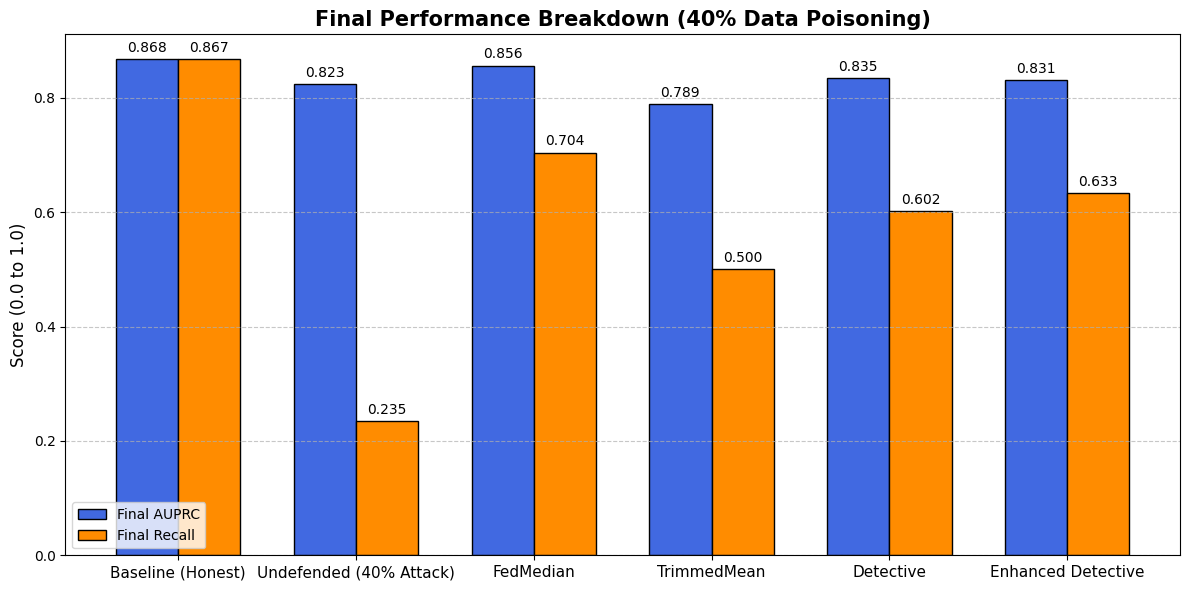

In [6]:
df_fl_base = pd.read_csv('results/50_rounds/results_baseline_r50.csv')
df_fl_atk40 = pd.read_csv('results/50_rounds/results_attack_40_r50.csv')
df_med40 = pd.read_csv('results/50_rounds/results_defense_Median_40_r50.csv')
df_trim40 = pd.read_csv('results/50_rounds/results_defense_TrimmedMean_40_r50.csv')
df_det40 = pd.read_csv('results/50_rounds/results_detective_40_r50.csv')
df_enh_det40 = pd.read_csv('results/50_rounds/results_enhanced_detective_40_r50.csv')

models = ['Baseline (Honest)', 'Undefended (40% Attack)', 'FedMedian', 'TrimmedMean', 'Detective', 'Enhanced Detective']
final_auprc = [
    df_fl_base.iloc[-1]['AUPRC'], df_fl_atk40.iloc[-1]['AUPRC'],
    df_med40.iloc[-1]['AUPRC'], df_trim40.iloc[-1]['AUPRC'], df_det40.iloc[-1]['AUPRC'], df_enh_det40.iloc[-1]['AUPRC']
]
final_recall = [
    df_fl_base.iloc[-1]['Recall'], df_fl_atk40.iloc[-1]['Recall'],
    df_med40.iloc[-1]['Recall'], df_trim40.iloc[-1]['Recall'], df_det40.iloc[-1]['Recall'], df_enh_det40.iloc[-1]['Recall']
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, final_auprc, width, label='Final AUPRC', color='royalblue', edgecolor='black')
rects2 = ax.bar(x + width/2, final_recall, width, label='Final Recall', color='darkorange', edgecolor='black')

ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('Final Performance Breakdown (40% Data Poisoning)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='lower left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.savefig('plot4_auprc_recall_scoreboard.png', dpi=300)
plt.show()

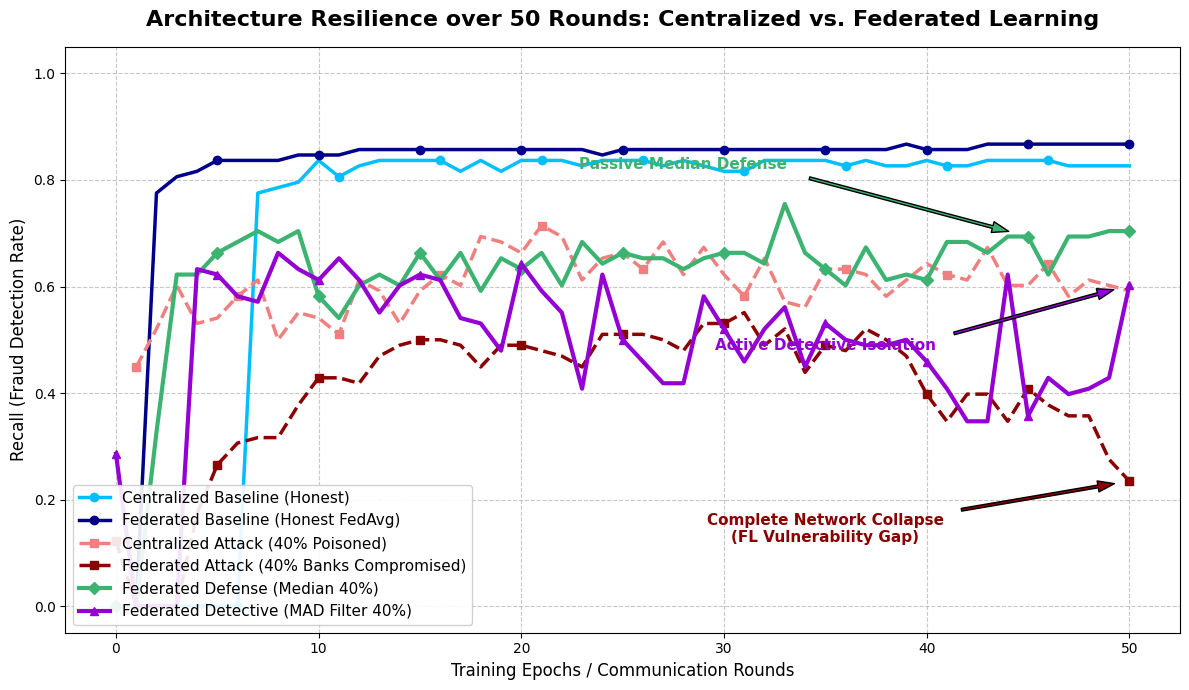

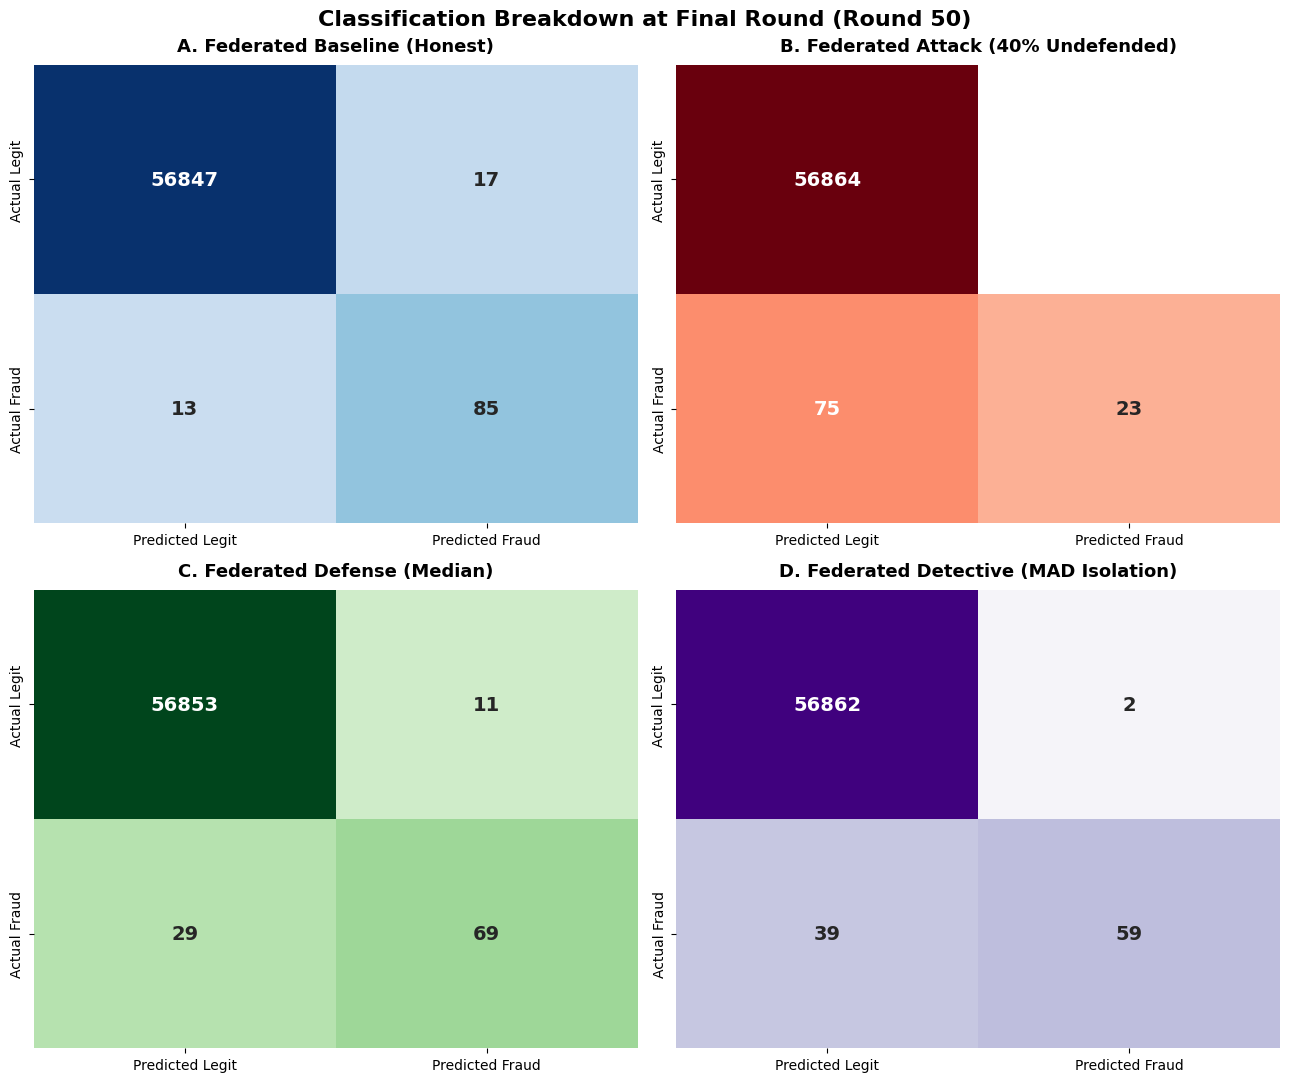

In [3]:
df_fl_base = pd.read_csv('results/50_rounds/results_baseline_r50.csv')
df_cent_base = pd.read_csv('results/50_rounds/results_centralized_baseline_r50.csv')

df_fl_atk40 = pd.read_csv('results/50_rounds/results_attack_40_r50.csv')
df_cent_atk40 = pd.read_csv('results/50_rounds/results_centralized_attack_40_r50.csv')

df_fl_med40 = pd.read_csv('results/50_rounds/results_defense_Median_40_r50.csv') 
df_fl_det40 = pd.read_csv('results/50_rounds/results_detective_40_r50.csv') 


plt.figure(figsize=(12, 7))

plt.plot(df_cent_base['Epoch'], df_cent_base['Recall'], 
         label='Centralized Baseline (Honest)', color='deepskyblue', linewidth=2.5, marker='o', markevery=5)
plt.plot(df_fl_base['Round'], df_fl_base['Recall'], 
         label='Federated Baseline (Honest FedAvg)', color='darkblue', linewidth=2.5, marker='o', markevery=5)

plt.plot(df_cent_atk40['Epoch'], df_cent_atk40['Recall'], 
         label='Centralized Attack (40% Poisoned)', color='lightcoral', linewidth=2.5, linestyle='--', marker='s', markevery=5)
plt.plot(df_fl_atk40['Round'], df_fl_atk40['Recall'], 
         label='Federated Attack (40% Banks Compromised)', color='darkred', linewidth=2.5, linestyle='--', marker='s', markevery=5)

# Plot Defenses (Greens and Purples)
plt.plot(df_fl_med40['Round'], df_fl_med40['Recall'], 
         label='Federated Defense (Median 40%)', color='mediumseagreen', linewidth=3, marker='D', markevery=5)
plt.plot(df_fl_det40['Round'], df_fl_det40['Recall'], 
         label='Federated Detective (MAD Filter 40%)', color='darkviolet', linewidth=3, marker='^', markevery=5)

plt.title('Architecture Resilience over 50 Rounds: Centralized vs. Federated Learning', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Epochs / Communication Rounds', fontsize=12)
plt.ylabel('Recall (Fraud Detection Rate)', fontsize=12)
plt.ylim(-0.05, 1.05) 
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)

plt.annotate('Complete Network Collapse\n(FL Vulnerability Gap)', 
             xy=(50, df_fl_atk40.iloc[-1]['Recall']), xytext=(35, 0.12), 
             arrowprops=dict(facecolor='darkred', shrink=0.08, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='darkred', ha='center')

plt.annotate('Passive Median Defense', 
             xy=(45, df_fl_med40.iloc[45]['Recall']), xytext=(28, 0.82), 
             arrowprops=dict(facecolor='mediumseagreen', shrink=0.08, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='mediumseagreen', ha='center')

plt.annotate('Active Detective Isolation', 
             xy=(50, df_fl_det40.iloc[-1]['Recall']), xytext=(35, 0.48), 
             arrowprops=dict(facecolor='darkviolet', shrink=0.08, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='darkviolet', ha='center')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Classification Breakdown at Final Round (Round 50)', fontsize=16, fontweight='bold', y=0.98)

def draw_confusion_matrix(df, ax, title, color_map):
    last_row = df.iloc[-1]
    cm = np.array([
        [int(last_row['TN']), int(last_row['FP'])],
        [int(last_row['FN']), int(last_row['TP'])]
    ])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, cbar=False, ax=ax,
                norm=mcolors.LogNorm(vmin=1, vmax=60000),
                xticklabels=['Predicted Legit', 'Predicted Fraud'], 
                yticklabels=['Actual Legit', 'Actual Fraud'],
                annot_kws={"size": 14, "weight": "bold"})
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(axis='both', which='major', labelsize=10)

draw_confusion_matrix(df_fl_base, axes[0, 0], 'A. Federated Baseline (Honest)', 'Blues')
draw_confusion_matrix(df_fl_atk40, axes[0, 1], 'B. Federated Attack (40% Undefended)', 'Reds')
draw_confusion_matrix(df_fl_med40, axes[1, 0], 'C. Federated Defense (Median)', 'Greens')
draw_confusion_matrix(df_fl_det40, axes[1, 1], 'D. Federated Detective (MAD Isolation)', 'Purples')

plt.tight_layout()
plt.show()

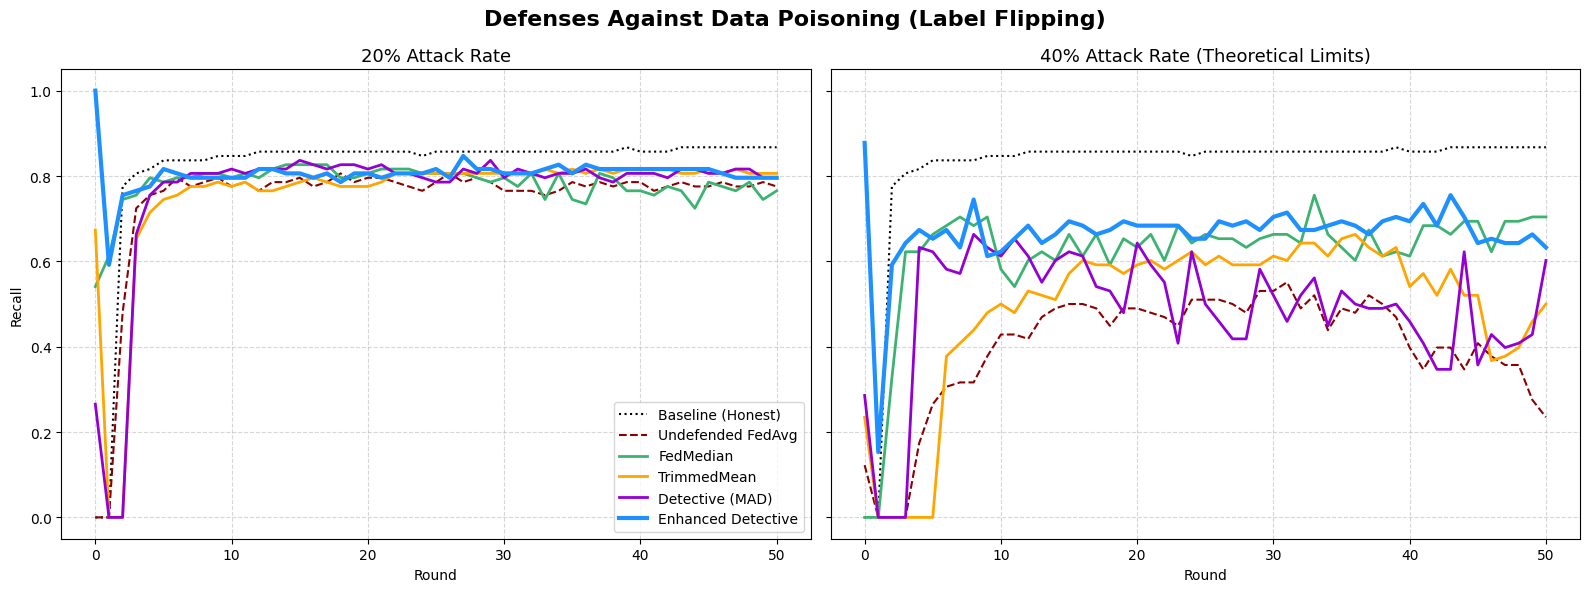

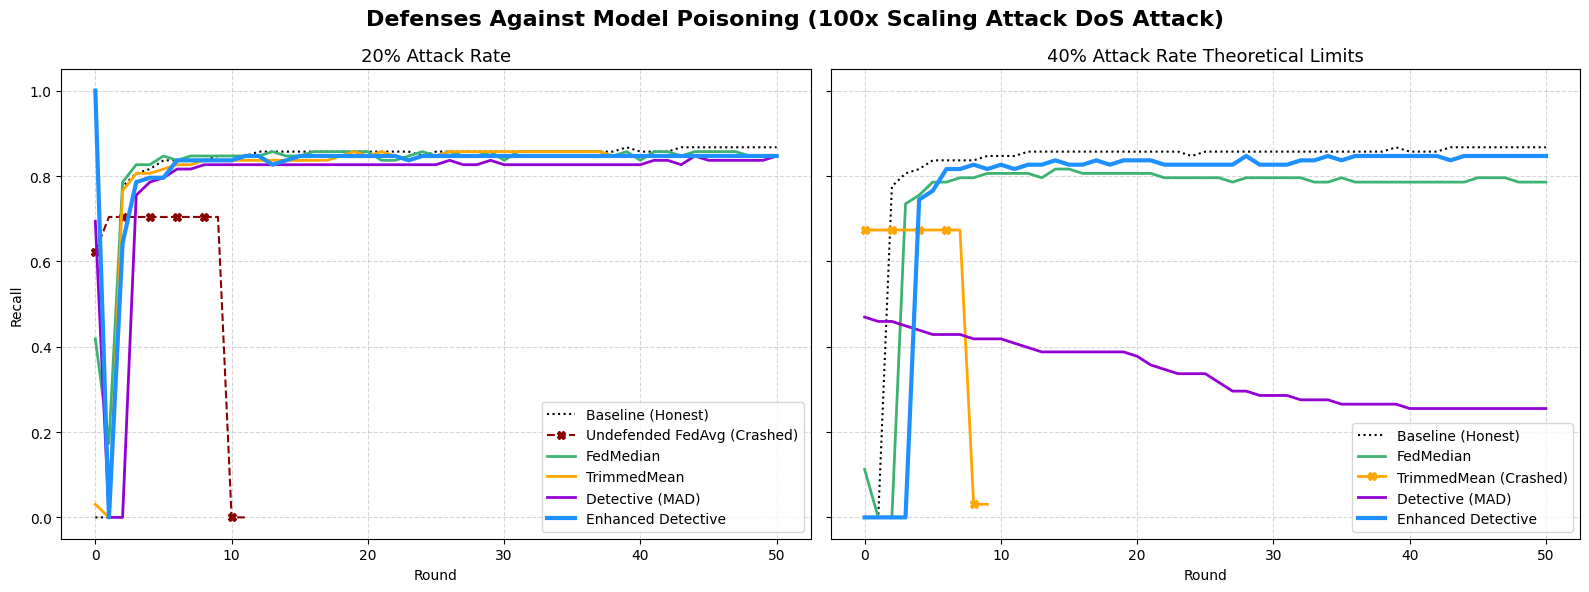

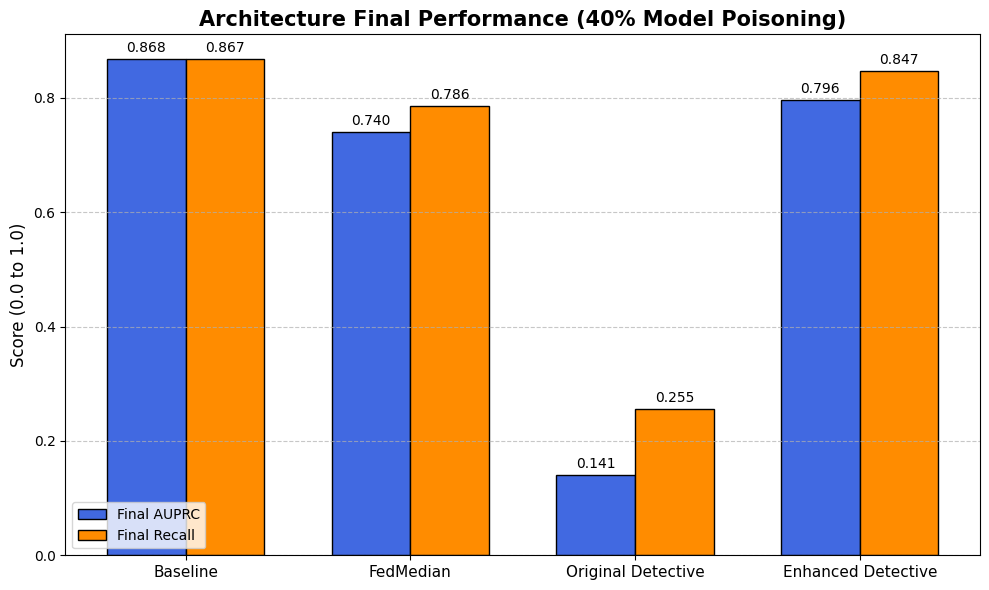

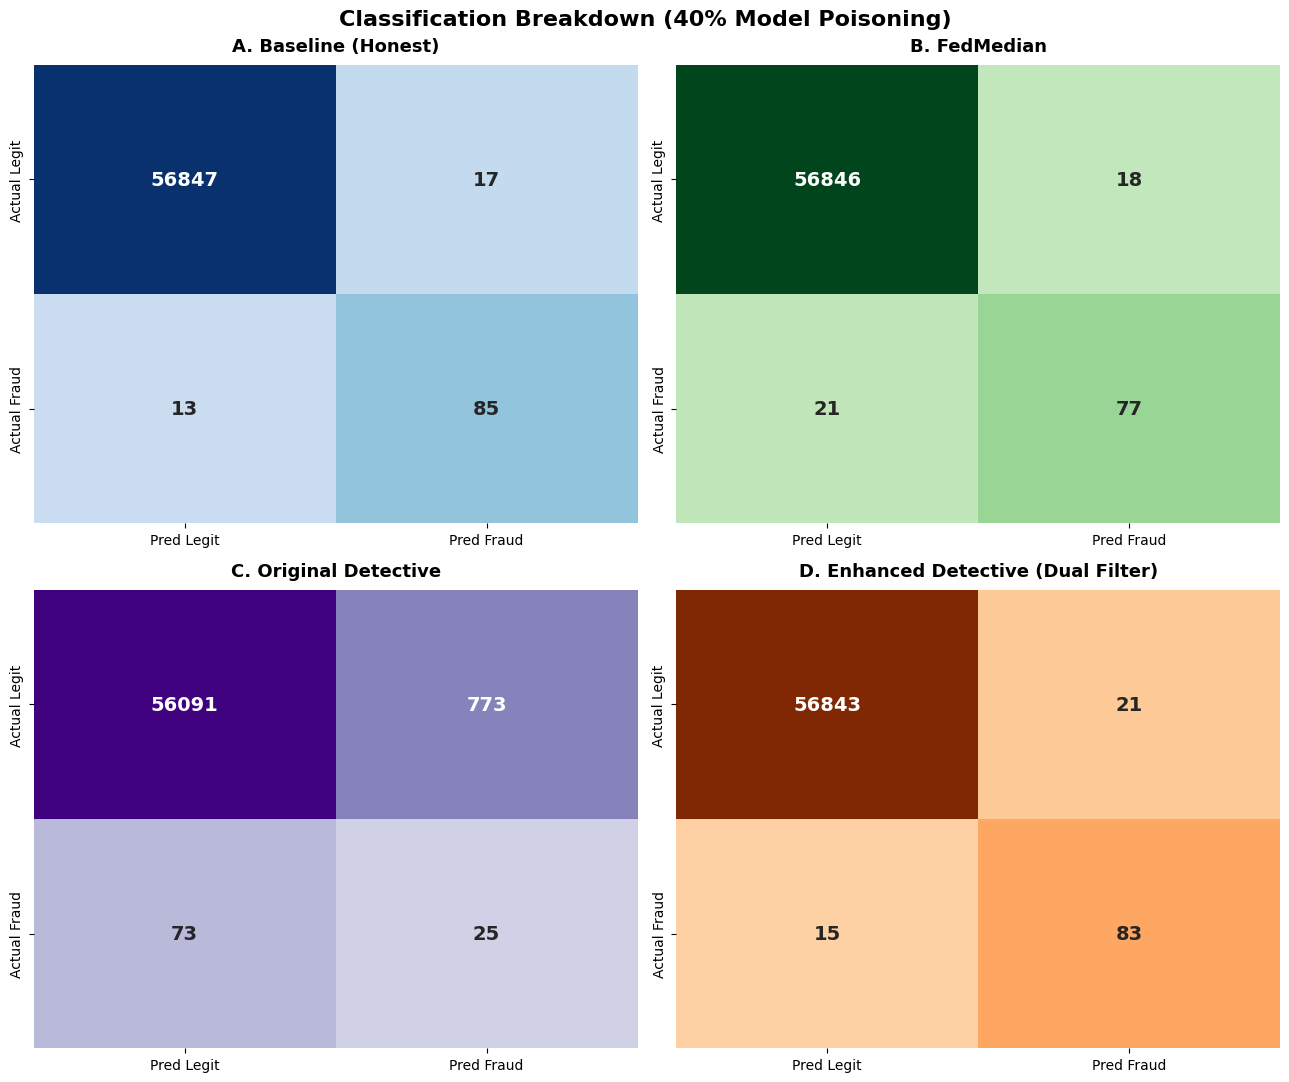

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

def load_data(filename):
    try:
        return pd.read_csv(f'{filename}')
    except FileNotFoundError:
        print(f"Warning: Could not find {filename}")
        return pd.DataFrame()

# Încărcarea datelor
df_fl_base = load_data('results/50_rounds/results_baseline_r50.csv')

# Data Poisoning
df_atk20 = load_data('results/50_rounds/results_attack_20_r50.csv')
df_med20 = load_data('results/50_rounds/results_defense_Median_20_r50.csv')
df_trim20 = load_data('results/50_rounds/results_defense_TrimmedMean_20_r50.csv')
df_det20 = load_data('results/50_rounds/results_detective_20_r50.csv')
df_edet20 = load_data('results/50_rounds/results_enhanced_detective_20_r50.csv')

df_fl_atk40 = load_data('results/50_rounds/results_attack_40_r50.csv')
df_med40 = load_data('results/50_rounds/results_defense_Median_40_r50.csv')
df_trim40 = load_data('results/50_rounds/results_defense_TrimmedMean_40_r50.csv')
df_det40 = load_data('results/50_rounds/results_detective_40_r50.csv')
df_edet40 = load_data('results/50_rounds/results_enhanced_detective_40_r50.csv')

# --- PLOT 1: DATA POISONING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Defenses Against Data Poisoning (Label Flipping)', fontsize=16, fontweight='bold')

for ax, rate, df_a, df_m, df_t, df_d, df_e in zip(axes, ['20%', '40%'], 
                                                 [df_atk20, df_fl_atk40], 
                                                 [df_med20, df_med40], 
                                                 [df_trim20, df_trim40], 
                                                 [df_det20, df_det40],
                                                 [df_edet20, df_edet40]):
    ax.plot(df_fl_base['Round'], df_fl_base['Recall'], label='Baseline (Honest)', color='black', linestyle=':')
    ax.plot(df_a['Round'], df_a['Recall'], label='Undefended FedAvg', color='darkred', linestyle='--')
    ax.plot(df_m['Round'], df_m['Recall'], label='FedMedian', color='mediumseagreen', linewidth=2)
    ax.plot(df_t['Round'], df_t['Recall'], label='TrimmedMean', color='orange', linewidth=2)
    ax.plot(df_d['Round'], df_d['Recall'], label='Detective (MAD)', color='darkviolet', linewidth=2)
    ax.plot(df_e['Round'], df_e['Recall'], label='Enhanced Detective', color='dodgerblue', linewidth=3)
    if rate == '40%':
        ax.set_title(f'{rate} Attack Rate (Theoretical Limits)', fontsize=13)
    else:
        ax.set_title(f'{rate} Attack Rate', fontsize=13)
    ax.set_xlabel('Round')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].set_ylabel('Recall')
axes[0].legend(loc='lower right')
plt.tight_layout()
plt.show()

# Încărcarea datelor pt Model Poisoning
df_m_atk20 = load_data('results/50_rounds/results_attack_20-model-poisoning_r50.csv')
df_m_med20 = load_data('results/50_rounds/results_defense_Median_20-model-poisoning_r50.csv')
df_m_trim20 = load_data('results/50_rounds/results_defense_TrimmedMean_20-model-poisoning_r50.csv')
df_m_det20 = load_data('results/50_rounds/results_detective_20-model-poisoning_r50.csv')
df_m_edet20 = load_data('results/50_rounds/results_enhanced_detective_20_r50-model-poisoning.csv')

df_m_atk40 = load_data('results/50_rounds/results_attack_40-model-poisoning_r50.csv')
df_m_med40 = load_data('results/50_rounds/results_defense_Median_40-model-poisoning_r50.csv')
df_m_trim40 = load_data('results/50_rounds/results_defense_TrimmedMean_40-model-poisoning_r50.csv')
df_m_det40 = load_data('results/50_rounds/results_detective_40-model-poisoning_r50.csv')
df_m_edet40 = load_data('results/50_rounds/results_enhanced_detective_40_r50-model_poisoning.csv')

# --- PLOT 2: MODEL POISONING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Defenses Against Model Poisoning (100x Scaling Attack DoS Attack)', fontsize=16, fontweight='bold')

axes[0].plot(df_fl_base['Round'], df_fl_base['Recall'], label='Baseline (Honest)', color='black', linestyle=':')
if not df_m_atk20.empty:
    axes[0].plot(df_m_atk20['Round'], df_m_atk20['Recall'], label='Undefended FedAvg (Crashed)', color='darkred', linestyle='--', marker='X', markevery=2)
axes[0].plot(df_m_med20['Round'], df_m_med20['Recall'], label='FedMedian', color='mediumseagreen', linewidth=2)
axes[0].plot(df_m_trim20['Round'], df_m_trim20['Recall'], label='TrimmedMean', color='orange', linewidth=2)
axes[0].plot(df_m_det20['Round'], df_m_det20['Recall'], label='Detective (MAD)', color='darkviolet', linewidth=2)
axes[0].plot(df_m_edet20['Round'], df_m_edet20['Recall'], label='Enhanced Detective', color='dodgerblue', linewidth=3)
axes[0].set_title('20% Attack Rate', fontsize=13)
axes[0].set_ylabel('Recall')
axes[0].set_xlabel('Round')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(df_fl_base['Round'], df_fl_base['Recall'], label='Baseline (Honest)', color='black', linestyle=':')
axes[1].plot(df_m_med40['Round'], df_m_med40['Recall'], label='FedMedian', color='mediumseagreen', linewidth=2)
if not df_m_trim40.empty:
    axes[1].plot(df_m_trim40['Round'], df_m_trim40['Recall'], label='TrimmedMean (Crashed)', color='orange', linewidth=2, marker='X', markevery=2)
axes[1].plot(df_m_det40['Round'], df_m_det40['Recall'], label='Detective (MAD)', color='darkviolet', linewidth=2)
axes[1].plot(df_m_edet40['Round'], df_m_edet40['Recall'], label='Enhanced Detective', color='dodgerblue', linewidth=3)
axes[1].set_title('40% Attack Rate Theoretical Limits', fontsize=13)
axes[1].set_xlabel('Round')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- PLOT 3: BAR CHART ---
models = ['Baseline', 'FedMedian', 'Original Detective', 'Enhanced Detective']
final_auprc = [
    df_fl_base.iloc[-1]['AUPRC'], df_m_med40.iloc[-1]['AUPRC'],
    df_m_det40.iloc[-1]['AUPRC'], df_m_edet40.iloc[-1]['AUPRC']
]
final_recall = [
    df_fl_base.iloc[-1]['Recall'], df_m_med40.iloc[-1]['Recall'],
    df_m_det40.iloc[-1]['Recall'], df_m_edet40.iloc[-1]['Recall']
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, final_auprc, width, label='Final AUPRC', color='royalblue', edgecolor='black')
rects2 = ax.bar(x + width/2, final_recall, width, label='Final Recall', color='darkorange', edgecolor='black')

ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('Architecture Final Performance (40% Model Poisoning)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='lower left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

# --- PLOT 4: CONFUSION MATRICES ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Classification Breakdown (40% Model Poisoning)', fontsize=16, fontweight='bold', y=0.98)

def draw_cm(df, ax, title, cmap):
    if df.empty: return
    last_row = df.iloc[-1]
    cm = np.array([[int(last_row['TN']), int(last_row['FP'])],
                   [int(last_row['FN']), int(last_row['TP'])]])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax,
                norm=mcolors.LogNorm(vmin=1, vmax=60000),
                xticklabels=['Pred Legit', 'Pred Fraud'], 
                yticklabels=['Actual Legit', 'Actual Fraud'],
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

draw_cm(df_fl_base, axes[0, 0], 'A. Baseline (Honest)', 'Blues')
draw_cm(df_m_med40, axes[0, 1], 'B. FedMedian', 'Greens')
draw_cm(df_m_det40, axes[1, 0], 'C. Original Detective', 'Purples')
draw_cm(df_m_edet40, axes[1, 1], 'D. Enhanced Detective (Dual Filter)', 'Oranges')

plt.tight_layout()
plt.show()